In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

print("Libraries imported successfully!")


Libraries imported successfully!


In [5]:
df = pd.read_csv("mtcars.csv")

df.head()

,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360,175,3.15,3.440,17.02,0,0,3,2


In [6]:
print("Number of Rows and Columns:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

Number of Rows and Columns:
(5, 12)

Column Names:
Index(['model', 'mpg', 'cyl', 'disp', 'hp', 'drat', 'wt', 'qsec', 'vs', 'am',
       'gear', 'carb'],
      dtype='str')

Data Types:
model        str
mpg      float64
cyl        int64
disp       int64
hp         int64
drat     float64
wt       float64
qsec     float64
vs         int64
am         int64
gear       int64
carb       int64
dtype: object


In [7]:
df.isnull().sum()


model    0
mpg      0
cyl      0
disp     0
hp       0
drat     0
wt       0
qsec     0
vs       0
am       0
gear     0
carb     0
dtype: int64

In [8]:
df.describe()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
count,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
mean,20.980000,6.000000,209.200000,119.600000,3.576000,2.894000,17.710000,0.400000,0.600000,3.600000,2.400000
std,1.473771,1.414214,100.255673,31.832373,0.422054,0.448907,1.256742,0.547723,0.547723,0.547723,1.516575
min,18.700000,4.000000,108.000000,93.000000,3.080000,2.320000,16.460000,0.000000,0.000000,3.000000,1.000000
25%,21.000000,6.000000,160.000000,110.000000,3.150000,2.620000,17.020000,0.000000,0.000000,3.000000,1.000000
50%,21.000000,6.000000,160.000000,110.000000,3.850000,2.875000,17.020000,0.000000,1.000000,4.000000,2.000000
75%,21.400000,6.000000,258.000000,110.000000,3.900000,3.215000,18.610000,1.000000,1.000000,4.000000,4.000000
max,22.800000,8.000000,360.000000,175.000000,3.900000,3.440000,19.440000,1.000000,1.000000,4.000000,4.000000


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   model   5 non-null      str    
 1   mpg     5 non-null      float64
 2   cyl     5 non-null      int64  
 3   disp    5 non-null      int64  
 4   hp      5 non-null      int64  
 5   drat    5 non-null      float64
 6   wt      5 non-null      float64
 7   qsec    5 non-null      float64
 8   vs      5 non-null      int64  
 9   am      5 non-null      int64  
 10  gear    5 non-null      int64  
 11  carb    5 non-null      int64  
dtypes: float64(4), int64(7), str(1)
memory usage: 612.0 bytes


In [10]:
df.fillna(df.mean(numeric_only=True), inplace=True)

df.head()

,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360,175,3.15,3.440,17.02,0,0,3,2


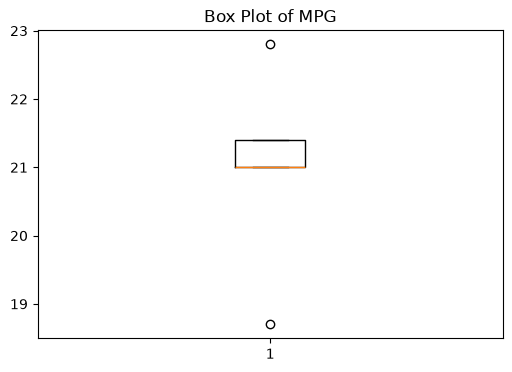

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.boxplot(df["mpg"])
plt.title("Box Plot of MPG")
plt.show()

In [12]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df["mpg_normalized"] = scaler.fit_transform(df[["mpg"]])

df[["mpg","mpg_normalized"]].head()

,mpg,mpg_normalized
0,21.0,0.560976
1,21.0,0.560976
2,22.8,1.000000
3,21.4,0.658537
4,18.7,0.000000


In [13]:
from sklearn.preprocessing import StandardScaler

standard = StandardScaler()

df["hp_standardized"] = standard.fit_transform(df[["hp"]])

df[["hp","hp_standardized"]].head()

,hp,hp_standardized
0,110,-0.337176
1,110,-0.337176
2,93,-0.934260
3,110,-0.337176
4,175,1.945789


In [14]:
df.groupby("cyl")["mpg"].mean()

cyl
4    22.800000
6    21.133333
8    18.700000
Name: mpg, dtype: float64

In [15]:
df["MPG_Category"] = pd.cut(
    df["mpg"],
    bins=3,
    labels=["Low", "Medium", "High"]
)

df[["mpg","MPG_Category"]].head()


,mpg,MPG_Category
0,21.0,Medium
1,21.0,Medium
2,22.8,High
3,21.4,Medium
4,18.7,Low


In [16]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["Model_Label"] = encoder.fit_transform(df["model"])

df[["model","Model_Label"]].head()

,model,Model_Label
0,Mazda RX4,3
1,Mazda RX4 Wag,4
2,Datsun 710,0
3,Hornet 4 Drive,1
4,Hornet Sportabout,2


In [17]:
df_encoded = pd.get_dummies(df, columns=["gear"])

df_encoded.head()

,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,carb,mpg_normalized,hp_standardized,MPG_Category,Model_Label,gear_3,gear_4
0,Mazda RX4,21.0,6,160,110,3.90,2.620,16.46,0,1,4,0.560976,-0.337176,Medium,3,False,True
1,Mazda RX4 Wag,21.0,6,160,110,3.90,2.875,17.02,0,1,4,0.560976,-0.337176,Medium,4,False,True
2,Datsun 710,22.8,4,108,93,3.85,2.320,18.61,1,1,1,1.000000,-0.934260,High,0,False,True
3,Hornet 4 Drive,21.4,6,258,110,3.08,3.215,19.44,1,0,1,0.658537,-0.337176,Medium,1,True,False
4,Hornet Sportabout,18.7,8,360,175,3.15,3.440,17.02,0,0,2,0.000000,1.945789,Low,2,True,False


In [18]:
df_reduced = df.drop(columns=["carb"])

df_reduced.head()

,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,mpg_normalized,hp_standardized,MPG_Category,Model_Label
0,Mazda RX4,21.0,6,160,110,3.90,2.620,16.46,0,1,4,0.560976,-0.337176,Medium,3
1,Mazda RX4 Wag,21.0,6,160,110,3.90,2.875,17.02,0,1,4,0.560976,-0.337176,Medium,4
2,Datsun 710,22.8,4,108,93,3.85,2.320,18.61,1,1,4,1.000000,-0.934260,High,0
3,Hornet 4 Drive,21.4,6,258,110,3.08,3.215,19.44,1,0,3,0.658537,-0.337176,Medium,1
4,Hornet Sportabout,18.7,8,360,175,3.15,3.440,17.02,0,0,3,0.000000,1.945789,Low,2


In [19]:
df.sample(5)

,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb,mpg_normalized,hp_standardized,MPG_Category,Model_Label
0,Mazda RX4,21.0,6,160,110,3.90,2.620,16.46,0,1,4,4,0.560976,-0.337176,Medium,3
4,Hornet Sportabout,18.7,8,360,175,3.15,3.440,17.02,0,0,3,2,0.000000,1.945789,Low,2
2,Datsun 710,22.8,4,108,93,3.85,2.320,18.61,1,1,4,1,1.000000,-0.934260,High,0
3,Hornet 4 Drive,21.4,6,258,110,3.08,3.215,19.44,1,0,3,1,0.658537,-0.337176,Medium,1
1,Mazda RX4 Wag,21.0,6,160,110,3.90,2.875,17.02,0,1,4,4,0.560976,-0.337176,Medium,4


In [20]:
df.to_csv("preprocessed_mtcars.csv", index=False)

print("Preprocessed dataset saved successfully!")

Preprocessed dataset saved successfully!
